# 11. 진단 및 검증 결과표

## 1. 목적

이 노트북은 2024년 기업정보화통계조사 최종 분석용 데이터셋을 기준으로 주모형과 확장모형의 진단 및 검증 결과를 정리한다. 이분산, 다중공선성, 과분산, 평행추세 적용 가능성, 순서형 종속변수 대응 여부를 확인하고, 중간보고서에 붙여넣을 수 있는 표와 해석 문단을 생성한다.

## 2. 설정값 및 저장 옵션

`SAVE_OUTPUTS=True`이면 표와 그림을 `output/tables`, `output/figure`에 저장한다. `False`이면 파일 저장 없이 노트북 화면에만 결과를 출력한다.

In [4]:
# 저장 옵션: 필요할 때만 True/False를 바꿔 실행
SAVE_OUTPUTS = False

from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

CWD = Path.cwd().resolve()
if (CWD / 'working').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'working').exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError('working 폴더가 있는 프로젝트 루트를 찾지 못했습니다.')
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "output" / ".matplotlib_cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string(index=False))
        else:
            print(obj)
    class Markdown(str):
        pass

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices, dmatrix

DATA_DIR = PROJECT_ROOT / "working" / "analysis"
TABLE_DIR = PROJECT_ROOT / "output" / "tables"
FIGURE_DIR = PROJECT_ROOT / "output" / "figure"

if SAVE_OUTPUTS:
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 한글 폰트 설정: 사용 가능한 폰트가 없으면 영어 fallback 사용
preferred_fonts = ["AppleGothic", "Malgun Gothic", "NanumGothic"]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
KOREAN_FONT_AVAILABLE = False
for font in preferred_fonts:
    if font in available_fonts:
        rcParams["font.family"] = font
        KOREAN_FONT_AVAILABLE = True
        break
rcParams["axes.unicode_minus"] = False

print(f"SAVE_OUTPUTS = {SAVE_OUTPUTS}")
print(f"프로젝트 폴더: {PROJECT_ROOT}")
print(f"한글 폰트 사용 가능 여부: {KOREAN_FONT_AVAILABLE}")

def df_to_markdown(dataframe):
    df_md = dataframe.copy()
    df_md = df_md.astype(object).where(pd.notna(df_md), "")
    headers = [str(c) for c in df_md.columns]
    rows = df_md.astype(str).values.tolist()
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        safe_row = [cell.replace("|", "\\|").replace("\n", "<br>") for cell in row]
        lines.append("| " + " | ".join(safe_row) + " |")
    return "\n".join(lines)


SAVE_OUTPUTS = False
프로젝트 폴더: /Users/yenarue/Downloads/ITM.89912(A)/연구 데이터
한글 폰트 사용 가능 여부: True


## 3. 데이터 로드 및 변수 확인

최종 분석용 데이터셋은 `working/analysis` 폴더에서만 찾는다. 여러 파일이 있으면 CSV, XLSX, Parquet 순으로 확인하고, 같은 확장자 안에서는 수정일이 가장 최신인 파일을 사용한다.

In [5]:
def find_analysis_file(data_dir):
    priority = ["*.csv", "*.xlsx", "*.parquet"]
    candidates = []
    for pattern in priority:
        files = sorted(data_dir.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
        if files:
            candidates = files
            break
    if not candidates:
        raise FileNotFoundError(f"최종 분석용 데이터셋을 찾을 수 없습니다: {data_dir}")
    return candidates[0]

analysis_file = find_analysis_file(DATA_DIR)
if analysis_file.suffix.lower() == ".csv":
    df = pd.read_csv(analysis_file)
elif analysis_file.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(analysis_file)
elif analysis_file.suffix.lower() == ".parquet":
    df = pd.read_parquet(analysis_file)
else:
    raise ValueError(f"지원하지 않는 파일 형식입니다: {analysis_file.suffix}")

N_TOTAL = len(df)
print(f"사용한 데이터 파일명: {analysis_file.name}")
print(f"전체 N: {N_TOTAL:,}")
print(f"변수 수: {df.shape[1]:,}")

required_vars = [
    "effect_proc_improve", "effect_average", "it_org_any", "ai_use_sum", "firm_size", "industry"
]
extension_vars = [
    "it_org_internal", "it_org_mixed", "it_org_outsource", "it_invest_sum", "it_invest_high", "ai_impl_sum", "ai_purpose_sum"
]
all_check_vars = required_vars + extension_vars

var_check = pd.DataFrame({
    "variable": all_check_vars,
    "required_type": ["필수"] * len(required_vars) + ["확장모형 관련"] * len(extension_vars),
    "exists": [v in df.columns for v in all_check_vars],
    "missing_n": [df[v].isna().sum() if v in df.columns else np.nan for v in all_check_vars],
    "valid_n": [df[v].notna().sum() if v in df.columns else np.nan for v in all_check_vars],
})

display(var_check)
missing_required = var_check.query("required_type == '필수' and exists == False")["variable"].tolist()
if missing_required:
    raise ValueError(f"필수 변수가 없습니다: {missing_required}")

need_check = []
missing_optional = var_check.query("required_type == '확장모형 관련' and exists == False")["variable"].tolist()
if missing_optional:
    need_check.append("확장모형 관련 변수 중 데이터에 없는 변수: " + ", ".join(missing_optional))
else:
    need_check.append("필수 변수와 확장모형 관련 변수가 모두 데이터에 존재함.")

사용한 데이터 파일명: nia_2024_analysis_total.csv
전체 N: 12,203
변수 수: 58


,variable,required_type,exists,missing_n,valid_n
0,effect_proc_improve,필수,True,0,12203
1,effect_average,필수,True,0,12203
2,it_org_any,필수,True,0,12203
3,ai_use_sum,필수,True,0,12203
4,firm_size,필수,True,0,12203
5,industry,필수,True,0,12203
6,it_org_internal,확장모형 관련,True,0,12203
7,it_org_mixed,확장모형 관련,True,0,12203
8,it_org_outsource,확장모형 관련,True,0,12203
9,it_invest_sum,확장모형 관련,True,0,12203


## 4. 이분산 진단

주요 OLS 모형을 일반 OLS로 적합한 뒤 Breusch-Pagan 검정과 White 검정을 수행한다. 잔차-적합값 그림은 각 모형별로 노트북에 출력하고, `SAVE_OUTPUTS=True`일 때만 PNG로 저장한다.

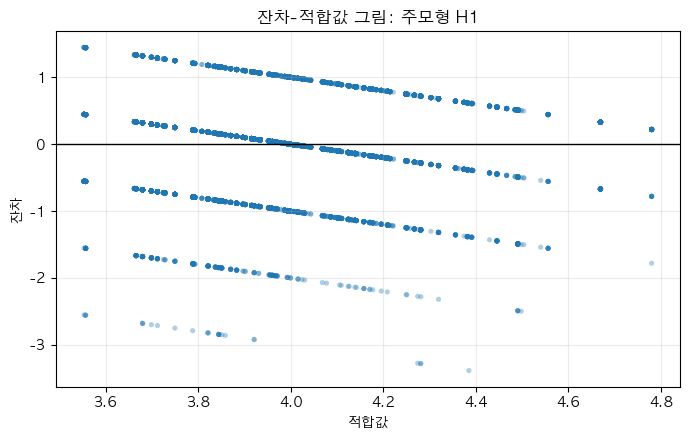

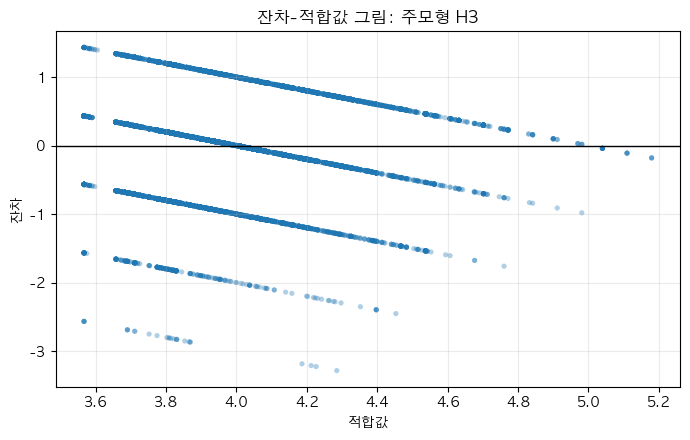

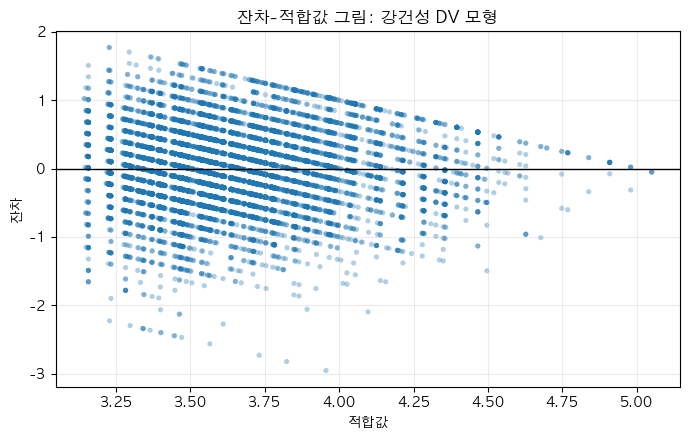

,model,formula,n,dropped_n,bp_lm_stat,bp_lm_pvalue,bp_f_stat,bp_f_pvalue,white_lm_stat,white_lm_pvalue,white_f_stat,white_f_pvalue,judgment,response
0,주모형 H1,effect_proc_improve ~ it_org_any + C(firm_size...,12203,0,456.109,0.0,24.897,0.0,579.381,0.0,7.553,0.0,이분산 가능성 있음,주요 회귀표에서 HC3 robust SE 사용
1,주모형 H3,effect_proc_improve ~ it_org_any * ai_use_sum ...,12203,0,462.390,0.0,22.845,0.0,666.437,0.0,5.816,0.0,이분산 가능성 있음,주요 회귀표에서 HC3 robust SE 사용
2,강건성 DV 모형,effect_average ~ it_org_any * ai_use_sum + C(f...,12203,0,325.521,0.0,15.897,0.0,592.030,0.0,5.134,0.0,이분산 가능성 있음,주요 회귀표에서 HC3 robust SE 사용


In [6]:
def stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

hetero_models = {
    "H1": {
        "label": "주모형 H1",
        "formula": "effect_proc_improve ~ it_org_any + C(firm_size) + C(industry)",
        "fig": "fig_diagnostics_residuals_model_h1.png",
    },
    "H3": {
        "label": "주모형 H3",
        "formula": "effect_proc_improve ~ it_org_any * ai_use_sum + C(firm_size) + C(industry)",
        "fig": "fig_diagnostics_residuals_model_h3.png",
    },
    "effect_average": {
        "label": "강건성 DV 모형",
        "formula": "effect_average ~ it_org_any * ai_use_sum + C(firm_size) + C(industry)",
        "fig": "fig_diagnostics_residuals_effect_average.png",
    },
}

ols_diagnostic_results = {}
hetero_rows = []

for model_key, spec in hetero_models.items():
    try:
        model = smf.ols(spec["formula"], data=df).fit()
        ols_diagnostic_results[model_key] = model
        resid = model.resid
        fitted = model.fittedvalues
        exog = model.model.exog
        bp = het_breuschpagan(resid, exog)
        wt = het_white(resid, exog)
        n_used = int(model.nobs)
        dropped_n = N_TOTAL - n_used
        hetero_rows.append({
            "model": spec["label"],
            "formula": spec["formula"],
            "n": n_used,
            "dropped_n": dropped_n,
            "bp_lm_stat": bp[0],
            "bp_lm_pvalue": bp[1],
            "bp_f_stat": bp[2],
            "bp_f_pvalue": bp[3],
            "white_lm_stat": wt[0],
            "white_lm_pvalue": wt[1],
            "white_f_stat": wt[2],
            "white_f_pvalue": wt[3],
            "judgment": "이분산 가능성 있음" if (bp[1] < 0.05 or wt[1] < 0.05) else "뚜렷한 이분산 근거 약함",
            "response": "주요 회귀표에서 HC3 robust SE 사용",
        })

        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.scatter(fitted, resid, alpha=0.35, s=14, edgecolor="none")
        ax.axhline(0, color="black", linewidth=1)
        ax.set_xlabel("Fitted values" if not KOREAN_FONT_AVAILABLE else "적합값")
        ax.set_ylabel("Residuals" if not KOREAN_FONT_AVAILABLE else "잔차")
        title = f"Residuals vs Fitted: {spec['label']}" if not KOREAN_FONT_AVAILABLE else f"잔차-적합값 그림: {spec['label']}"
        ax.set_title(title)
        ax.grid(alpha=0.25)
        fig.tight_layout()
        if SAVE_OUTPUTS:
            fig.savefig(FIGURE_DIR / spec["fig"], dpi=300, bbox_inches="tight")
        plt.show()
    except Exception as e:
        hetero_rows.append({
            "model": spec["label"],
            "formula": spec["formula"],
            "n": np.nan,
            "dropped_n": np.nan,
            "bp_lm_stat": np.nan,
            "bp_lm_pvalue": np.nan,
            "bp_f_stat": np.nan,
            "bp_f_pvalue": np.nan,
            "white_lm_stat": np.nan,
            "white_lm_pvalue": np.nan,
            "white_f_stat": np.nan,
            "white_f_pvalue": np.nan,
            "judgment": "검정 실패",
            "response": str(e),
        })
        need_check.append(f"이분산 진단 실패: {spec['label']} - {e}")

hetero_table = pd.DataFrame(hetero_rows)
for col in ["bp_lm_stat", "bp_lm_pvalue", "bp_f_stat", "bp_f_pvalue", "white_lm_stat", "white_lm_pvalue", "white_f_stat", "white_f_pvalue"]:
    hetero_table[col] = pd.to_numeric(hetero_table[col], errors="coerce").round(3)

display(hetero_table)

if SAVE_OUTPUTS:
    hetero_table.to_csv(TABLE_DIR / "table7a_heteroskedasticity_tests.csv", index=False, encoding="utf-8-sig")

## 5. 다중공선성 진단

주모형 H3와 확장모형 D의 설계행렬을 만든 뒤 VIF를 계산한다. 상수항은 VIF 계산표에서 제외한다. 보고서용 판단은 핵심 변수 VIF와 전체 최대 VIF를 함께 확인한다.

In [7]:
def vif_note(v):
    if pd.isna(v) or np.isinf(v):
        return "확인 필요"
    if v >= 10:
        return "높음"
    if v >= 5:
        return "주의"
    return "양호"

def compute_vif(formula, data, model_name):
    y, X = dmatrices(formula, data=data, return_type="dataframe")
    X = X.loc[:, X.columns != "Intercept"]
    rows = []
    for i, col in enumerate(X.columns):
        try:
            v = variance_inflation_factor(X.values, i)
        except Exception:
            v = np.nan
        rows.append({
            "model_name": model_name,
            "variable": col,
            "vif": v,
            "note": vif_note(v),
        })
    out = pd.DataFrame(rows)
    out["vif"] = pd.to_numeric(out["vif"], errors="coerce").round(3)
    return out, X.shape[0], X.shape[1]

main_h3_formula = "effect_proc_improve ~ it_org_any * ai_use_sum + C(firm_size) + C(industry)"
extended_terms = ["it_org_any * ai_use_sum", "it_invest_sum", "ai_impl_sum", "ai_purpose_sum", "C(firm_size)", "C(industry)"]
if "it_invest_high" in df.columns:
    extended_terms.insert(2, "it_invest_high")
extended_d_formula = "effect_proc_improve ~ " + " + ".join(extended_terms)

try:
    vif_main, vif_main_n, vif_main_p = compute_vif(main_h3_formula, df, "주모형 H3")
except Exception as e:
    vif_main = pd.DataFrame(columns=["model_name", "variable", "vif", "note"])
    vif_main_n, vif_main_p = np.nan, np.nan
    need_check.append(f"주모형 H3 VIF 계산 실패: {e}")

try:
    vif_extended, vif_extended_n, vif_extended_p = compute_vif(extended_d_formula, df, "확장모형 D")
except Exception as e:
    vif_extended = pd.DataFrame(columns=["model_name", "variable", "vif", "note"])
    vif_extended_n, vif_extended_p = np.nan, np.nan
    need_check.append(f"확장모형 D VIF 계산 실패: {e}")

print(f"주모형 H3 VIF 설계행렬: N={vif_main_n}, 변수 수={vif_main_p}")
display(vif_main)
print(f"확장모형 D VIF 설계행렬: N={vif_extended_n}, 변수 수={vif_extended_p}")
display(vif_extended)

if SAVE_OUTPUTS:
    vif_main.to_csv(TABLE_DIR / "table7b_vif_main_model.csv", index=False, encoding="utf-8-sig")
    vif_extended.to_csv(TABLE_DIR / "table7c_vif_extended_model.csv", index=False, encoding="utf-8-sig")

주모형 H3 VIF 설계행렬: N=12203, 변수 수=21


,model_name,variable,vif,note
0,주모형 H3,C(firm_size)[T.2],1.809,양호
1,주모형 H3,C(firm_size)[T.3],1.605,양호
2,주모형 H3,C(firm_size)[T.4],1.293,양호
3,주모형 H3,C(industry)[T.2],1.711,양호
4,주모형 H3,C(industry)[T.3],1.043,양호
5,주모형 H3,C(industry)[T.4],1.309,양호
6,주모형 H3,C(industry)[T.5],1.244,양호
7,주모형 H3,C(industry)[T.6],1.134,양호
8,주모형 H3,C(industry)[T.7],1.093,양호
9,주모형 H3,C(industry)[T.8],1.228,양호


확장모형 D VIF 설계행렬: N=12203, 변수 수=25


,model_name,variable,vif,note
0,확장모형 D,C(firm_size)[T.2],1.842,양호
1,확장모형 D,C(firm_size)[T.3],1.667,양호
2,확장모형 D,C(firm_size)[T.4],1.340,양호
3,확장모형 D,C(industry)[T.2],2.373,양호
4,확장모형 D,C(industry)[T.3],1.088,양호
5,확장모형 D,C(industry)[T.4],1.687,양호
6,확장모형 D,C(industry)[T.5],1.574,양호
7,확장모형 D,C(industry)[T.6],1.230,양호
8,확장모형 D,C(industry)[T.7],1.179,양호
9,확장모형 D,C(industry)[T.8],1.574,양호


## 6. 과분산 진단

`ai_use_sum`의 평균, 표본분산, 0의 비율, 분산/평균 비율을 계산한다. 추가로 Poisson 모형의 Pearson chi-square / df 값을 계산해 카운트형 대안모형 필요성을 점검한다.

In [8]:
overdisp_rows = []
try:
    s = df["ai_use_sum"].dropna()
    ai_mean = s.mean()
    ai_var = s.var(ddof=1)
    zero_rate = (s == 0).mean()
    var_mean_ratio = ai_var / ai_mean if ai_mean != 0 else np.nan

    poisson_formula = "ai_use_sum ~ it_org_any + C(firm_size) + C(industry)"
    poisson_model = smf.glm(poisson_formula, data=df, family=sm.families.Poisson()).fit()
    pearson_chi2_df = poisson_model.pearson_chi2 / poisson_model.df_resid if poisson_model.df_resid > 0 else np.nan

    overdispersion_possible = (var_mean_ratio > 1.5) or (pearson_chi2_df > 1.5)
    overdisp_rows.append({
        "variable": "ai_use_sum",
        "n": int(s.shape[0]),
        "mean": ai_mean,
        "sample_variance": ai_var,
        "zero_rate": zero_rate,
        "variance_mean_ratio": var_mean_ratio,
        "poisson_pearson_chi2_df": pearson_chi2_df,
        "judgment": "과분산 가능성 있음" if overdispersion_possible else "과분산 가능성 크지 않음",
        "response": "Poisson과 Negative Binomial 대안모형 함께 검토" if overdispersion_possible else "Poisson 대안모형 검토로 충분",
    })
except Exception as e:
    overdisp_rows.append({
        "variable": "ai_use_sum",
        "n": np.nan,
        "mean": np.nan,
        "sample_variance": np.nan,
        "zero_rate": np.nan,
        "variance_mean_ratio": np.nan,
        "poisson_pearson_chi2_df": np.nan,
        "judgment": "계산 실패",
        "response": str(e),
    })
    need_check.append(f"과분산 진단 실패: {e}")

overdisp_table = pd.DataFrame(overdisp_rows)
for col in ["mean", "sample_variance", "zero_rate", "variance_mean_ratio", "poisson_pearson_chi2_df"]:
    overdisp_table[col] = pd.to_numeric(overdisp_table[col], errors="coerce").round(3)

display(overdisp_table)

if SAVE_OUTPUTS:
    overdisp_table.to_csv(TABLE_DIR / "table7d_overdispersion_check.csv", index=False, encoding="utf-8-sig")

,variable,n,mean,sample_variance,zero_rate,variance_mean_ratio,poisson_pearson_chi2_df,judgment,response
0,ai_use_sum,12203,0.877,1.601,0.585,1.826,1.738,과분산 가능성 있음,Poisson과 Negative Binomial 대안모형 함께 검토


## 7. 평행추세 적용 여부 검토

평행추세 검정은 일반적으로 처치 전후 여러 시점의 패널 또는 반복 관측 자료가 있어야 적용할 수 있다. 본 데이터가 2024년 단일 연도 단면자료인지, 연도 변수와 반복 기업 ID 구조가 있는지 확인한다.

In [9]:
year_candidates = [c for c in df.columns if c.lower() in ["year", "survey_year", "base_year"] or "year" in c.lower() or "연도" in c]
id_candidates = [c for c in df.columns if c.lower() in ["id", "firm_id", "company_id", "biz_id", "corp_id"] or "id" in c.lower() or "기업" in c]

year_summary = []
for c in year_candidates:
    vals = df[c].dropna().unique()
    year_summary.append(f"{c}: {len(vals)}개 고유값({', '.join(map(str, sorted(vals)[:5]))}{'...' if len(vals) > 5 else ''})")

id_summary = []
for c in id_candidates:
    nunique = df[c].nunique(dropna=True)
    max_count = df[c].value_counts(dropna=True).max() if nunique > 0 else np.nan
    id_summary.append(f"{c}: 고유값 {nunique}, 최대 반복 {max_count}")

has_multi_year = False
if year_candidates:
    for c in year_candidates:
        if df[c].dropna().nunique() > 1:
            has_multi_year = True
            break

has_repeated_id = False
for c in id_candidates:
    vc = df[c].value_counts(dropna=True)
    if len(vc) and vc.max() > 1:
        has_repeated_id = True
        break

parallel_applicable = has_multi_year and has_repeated_id
parallel_table = pd.DataFrame([
    {
        "check_item": "연도 변수 존재 및 다년도 여부",
        "result": "; ".join(year_summary) if year_summary else "명시적 연도 변수 확인되지 않음",
        "judgment": "다년도 가능성 있음" if has_multi_year else "2024년 단일연도 단면자료로 판단",
    },
    {
        "check_item": "동일 기업 반복 관측 여부",
        "result": "; ".join(id_summary[:8]) if id_summary else "명시적 기업 ID 변수 확인되지 않음",
        "judgment": "반복 관측 가능성 있음" if has_repeated_id else "패널 반복 관측 구조 확인되지 않음",
    },
    {
        "check_item": "평행추세 검정 적용 가능성",
        "result": "다년도 및 반복 기업 구조가 모두 필요",
        "judgment": "적용 가능" if parallel_applicable else "적용하지 않음",
    },
])

display(parallel_table)

if not parallel_applicable:
    need_check.append("본 분석 데이터는 2024년 단일연도 단면자료로 판단되어 평행추세 검정은 원칙적으로 적용하지 않음.")

if SAVE_OUTPUTS:
    parallel_table.to_csv(TABLE_DIR / "table7e_parallel_trend_applicability.csv", index=False, encoding="utf-8-sig")

,check_item,result,judgment
0,연도 변수 존재 및 다년도 여부,year: 1개 고유값(2024),2024년 단일연도 단면자료로 판단
1,동일 기업 반복 관측 여부,"ai_use_image_video_recognition: 고유값 2, 최대 반복 9040",반복 관측 가능성 있음
2,평행추세 검정 적용 가능성,다년도 및 반복 기업 구조가 모두 필요,적용하지 않음


## 8. 진단/검증 요약표

각 진단 결과를 보고서 본문 또는 부록에 넣을 수 있는 요약표로 정리한다.

In [10]:
def fmt_p(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<.001"
    return f"{p:.3f}"

def max_vif_text(vif_table):
    if vif_table.empty or vif_table["vif"].dropna().empty:
        return "VIF 계산 실패"
    idx = vif_table["vif"].astype(float).idxmax()
    row = vif_table.loc[idx]
    return f"최대 VIF={row['vif']:.3f} ({row['variable']})"

bp_sig_count = int((pd.to_numeric(hetero_table["bp_lm_pvalue"], errors="coerce") < 0.05).sum()) if not hetero_table.empty else 0
white_sig_count = int((pd.to_numeric(hetero_table["white_lm_pvalue"], errors="coerce") < 0.05).sum()) if not hetero_table.empty else 0
hetero_result = f"BP 유의 모형 {bp_sig_count}개, White 유의 모형 {white_sig_count}개"

main_max_vif = max_vif_text(vif_main)
ext_max_vif = max_vif_text(vif_extended)
core_vifs = pd.concat([vif_main, vif_extended], ignore_index=True)
core_vif_warn = core_vifs[core_vifs["note"].isin(["주의", "높음"])]
vif_result = f"주모형 {main_max_vif}; 확장모형 {ext_max_vif}"

od = overdisp_table.iloc[0] if not overdisp_table.empty else pd.Series(dtype=object)
overdisp_result = f"평균={od.get('mean', np.nan)}, 분산/평균={od.get('variance_mean_ratio', np.nan)}, Pearson chi2/df={od.get('poisson_pearson_chi2_df', np.nan)}"
parallel_judgment = parallel_table.loc[parallel_table["check_item"] == "평행추세 검정 적용 가능성", "judgment"].iloc[0]

ordered_response = "종속변수 effect_proc_improve가 순서형이므로 Ordered Logit 대안모형을 별도 검토"

summary_rows = [
    {
        "진단 항목": "이분산",
        "대상 모형/변수": "주모형 H1, 주모형 H3, effect_average 강건성 DV 모형",
        "진단 방법": "Breusch-Pagan test, White test, 잔차-적합값 그림",
        "주요 결과": hetero_result,
        "판단": "이분산 가능성 고려 필요" if (bp_sig_count > 0 or white_sig_count > 0) else "뚜렷한 이분산 근거 약함",
        "대응": "주요 회귀표에서 HC3 robust standard error 사용",
        "보고 위치": "본문 진단 요약 및 부록 Table 7A",
    },
    {
        "진단 항목": "다중공선성",
        "대상 모형/변수": "주모형 H3 및 확장모형 D 설계행렬",
        "진단 방법": "Variance Inflation Factor (VIF)",
        "주요 결과": vif_result,
        "판단": "일부 변수 주의" if not core_vif_warn.empty else "전반적으로 양호",
        "대응": "확장모형은 부록용 탐색분석으로 제시하고 핵심 해석은 주모형 중심",
        "보고 위치": "부록 VIF 진단표",
    },
    {
        "진단 항목": "과분산",
        "대상 모형/변수": "ai_use_sum",
        "진단 방법": "분산/평균 비율, Poisson Pearson chi-square / df",
        "주요 결과": overdisp_result,
        "판단": od.get("judgment", "확인 필요"),
        "대응": od.get("response", "확인 필요"),
        "보고 위치": "대안모형 및 진단 요약",
    },
    {
        "진단 항목": "평행추세",
        "대상 모형/변수": "2024년 기업 단면자료 구조",
        "진단 방법": "연도 변수 및 반복 기업 ID 구조 확인",
        "주요 결과": parallel_judgment,
        "판단": "평행추세 검정 해당 없음" if parallel_judgment != "적용 가능" else "추가 검토 가능",
        "대응": "단면자료 기반 예비적 연관성 분석으로 해석 제한",
        "보고 위치": "본문 한계 및 확인 필요 사항",
    },
    {
        "진단 항목": "순서형 DV 대응",
        "대상 모형/변수": "effect_proc_improve",
        "진단 방법": "OLS 주모형과 Ordered Logit 대안모형 비교",
        "주요 결과": "Ordered Logit 대안모형을 별도 노트북에서 검토",
        "판단": "순서형 척도 특성 반영 필요",
        "대응": ordered_response,
        "보고 위치": "대안모형/강건성 분석 표",
    },
]

summary_table = pd.DataFrame(summary_rows)
display(summary_table)

if SAVE_OUTPUTS:
    summary_table.to_csv(TABLE_DIR / "table7_model_diagnostics_summary.csv", index=False, encoding="utf-8-sig")
    (TABLE_DIR / "table7_model_diagnostics_summary.md").write_text(
        "# Table 7. 진단 및 검증 요약표\n\n" + df_to_markdown(summary_table), encoding="utf-8"
    )

,진단 항목,대상 모형/변수,진단 방법,주요 결과,판단,대응,보고 위치
0,이분산,"주모형 H1, 주모형 H3, effect_average 강건성 DV 모형","Breusch-Pagan test, White test, 잔차-적합값 그림","BP 유의 모형 3개, White 유의 모형 3개",이분산 가능성 고려 필요,주요 회귀표에서 HC3 robust standard error 사용,본문 진단 요약 및 부록 Table 7A
1,다중공선성,주모형 H3 및 확장모형 D 설계행렬,Variance Inflation Factor (VIF),주모형 최대 VIF=4.047 (it_org_any:ai_use_sum); 확장모형...,일부 변수 주의,확장모형은 부록용 탐색분석으로 제시하고 핵심 해석은 주모형 중심,부록 VIF 진단표
2,과분산,ai_use_sum,"분산/평균 비율, Poisson Pearson chi-square / df","평균=0.877, 분산/평균=1.826, Pearson chi2/df=1.738",과분산 가능성 있음,Poisson과 Negative Binomial 대안모형 함께 검토,대안모형 및 진단 요약
3,평행추세,2024년 기업 단면자료 구조,연도 변수 및 반복 기업 ID 구조 확인,적용하지 않음,평행추세 검정 해당 없음,단면자료 기반 예비적 연관성 분석으로 해석 제한,본문 한계 및 확인 필요 사항
4,순서형 DV 대응,effect_proc_improve,OLS 주모형과 Ordered Logit 대안모형 비교,Ordered Logit 대안모형을 별도 노트북에서 검토,순서형 척도 특성 반영 필요,종속변수 effect_proc_improve가 순서형이므로 Ordered Logit...,대안모형/강건성 분석 표


## 9. 보고서용 해석 문단

아래 문단은 중간보고서의 진단 및 검증 설명에 바로 붙여넣을 수 있도록 작성한다.

In [11]:
h1_bp = hetero_table.loc[hetero_table["model"] == "주모형 H1", "bp_lm_pvalue"].iloc[0] if "주모형 H1" in hetero_table["model"].values else np.nan
h3_bp = hetero_table.loc[hetero_table["model"] == "주모형 H3", "bp_lm_pvalue"].iloc[0] if "주모형 H3" in hetero_table["model"].values else np.nan
h3_white = hetero_table.loc[hetero_table["model"] == "주모형 H3", "white_lm_pvalue"].iloc[0] if "주모형 H3" in hetero_table["model"].values else np.nan
main_max = vif_main["vif"].max() if not vif_main.empty else np.nan
ext_max = vif_extended["vif"].max() if not vif_extended.empty else np.nan
warn_vars = core_vif_warn[["model_name", "variable", "vif", "note"]].to_dict("records") if not core_vif_warn.empty else []
warn_text = "; ".join([f"{r['model_name']} {r['variable']} VIF={r['vif']}({r['note']})" for r in warn_vars]) if warn_vars else "VIF 5 이상 변수는 확인되지 않았다"

interpretation_sentences = [
    f"이분산 진단 결과, Breusch-Pagan 검정의 p-value는 주모형 H1에서 {fmt_p(float(h1_bp))}, 주모형 H3에서 {fmt_p(float(h3_bp))}로 나타났으며, H3의 White 검정 p-value는 {fmt_p(float(h3_white))}로 확인되었다.",
    "일부 검정에서 이분산 가능성을 배제하기 어렵기 때문에, 본문 주모형과 확장모형의 회귀표에서는 HC3 robust standard error를 사용하였다.",
    f"다중공선성 진단에서 주모형 H3의 최대 VIF는 {main_max:.3f}, 확장모형 D의 최대 VIF는 {ext_max:.3f}로 나타났으며, {warn_text}.",
    f"카운트형 변수 ai_use_sum의 평균은 {float(od.get('mean')):.3f}, 표본분산은 {float(od.get('sample_variance')):.3f}, 0의 비율은 {float(od.get('zero_rate'))*100:.1f}%였고, 분산/평균 비율은 {float(od.get('variance_mean_ratio')):.3f}로 나타났다.",
    f"Poisson 모형의 Pearson chi-square/df는 {float(od.get('poisson_pearson_chi2_df')):.3f}로 계산되어, Poisson과 Negative Binomial 대안모형을 함께 검토할 필요가 있다.",
    "평행추세 검정은 처치 전후 복수 시점의 패널 구조가 필요하지만, 본 분석 데이터는 2024년 단일연도 기업 단면자료로 판단되어 원칙적으로 적용하지 않았다.",
    "따라서 본 결과는 인과효과 검증이라기보다 주모형과 확장모형의 예비적 연관성을 진단하고, 강건한 표준오차와 대안모형 사용의 필요성을 확인하는 보조분석으로 해석한다.",
]
interpretation_text = "\n".join([f"{i+1}. {s}" for i, s in enumerate(interpretation_sentences)])
display(Markdown(interpretation_text))

if SAVE_OUTPUTS:
    (TABLE_DIR / "model_diagnostics_interpretation.md").write_text(
        "# 진단 및 검증 결과 해석 문단\n\n" + interpretation_text, encoding="utf-8"
    )

1. 이분산 진단 결과, Breusch-Pagan 검정의 p-value는 주모형 H1에서 <.001, 주모형 H3에서 <.001로 나타났으며, H3의 White 검정 p-value는 <.001로 확인되었다.
2. 일부 검정에서 이분산 가능성을 배제하기 어렵기 때문에, 본문 주모형과 확장모형의 회귀표에서는 HC3 robust standard error를 사용하였다.
3. 다중공선성 진단에서 주모형 H3의 최대 VIF는 4.047, 확장모형 D의 최대 VIF는 9.178로 나타났으며, 확장모형 D ai_use_sum VIF=7.881(주의); 확장모형 D it_invest_sum VIF=9.178(주의).
4. 카운트형 변수 ai_use_sum의 평균은 0.877, 표본분산은 1.601, 0의 비율은 58.5%였고, 분산/평균 비율은 1.826로 나타났다.
5. Poisson 모형의 Pearson chi-square/df는 1.738로 계산되어, Poisson과 Negative Binomial 대안모형을 함께 검토할 필요가 있다.
6. 평행추세 검정은 처치 전후 복수 시점의 패널 구조가 필요하지만, 본 분석 데이터는 2024년 단일연도 기업 단면자료로 판단되어 원칙적으로 적용하지 않았다.
7. 따라서 본 결과는 인과효과 검증이라기보다 주모형과 확장모형의 예비적 연관성을 진단하고, 강건한 표준오차와 대안모형 사용의 필요성을 확인하는 보조분석으로 해석한다.

## 10. 확인 필요 사항

분석 과정에서 확인이 필요한 변수, 검정 실패, 해석상 주의점을 정리한다.

In [12]:
saved_files = []
if SAVE_OUTPUTS:
    saved_files = [
        TABLE_DIR / "table7a_heteroskedasticity_tests.csv",
        TABLE_DIR / "table7b_vif_main_model.csv",
        TABLE_DIR / "table7c_vif_extended_model.csv",
        TABLE_DIR / "table7d_overdispersion_check.csv",
        TABLE_DIR / "table7e_parallel_trend_applicability.csv",
        TABLE_DIR / "table7_model_diagnostics_summary.csv",
        TABLE_DIR / "table7_model_diagnostics_summary.md",
        TABLE_DIR / "model_diagnostics_interpretation.md",
        FIGURE_DIR / "fig_diagnostics_residuals_model_h1.png",
        FIGURE_DIR / "fig_diagnostics_residuals_model_h3.png",
        FIGURE_DIR / "fig_diagnostics_residuals_effect_average.png",
    ]

final_report = {
    "사용한 데이터 파일명": analysis_file.name,
    "전체 N": N_TOTAL,
    "저장 여부": SAVE_OUTPUTS,
    "저장 파일 목록": [str(p.relative_to(PROJECT_ROOT)) for p in saved_files if p.exists()] if SAVE_OUTPUTS else [],
    "확인 필요 사항": need_check,
}

print("사용한 데이터 파일명:", final_report["사용한 데이터 파일명"])
print("전체 N:", f"{N_TOTAL:,}")
print("저장 여부:", SAVE_OUTPUTS)
print("저장 파일 목록:")
if SAVE_OUTPUTS:
    for p in final_report["저장 파일 목록"]:
        print("-", p)
else:
    print("- SAVE_OUTPUTS=False이므로 저장하지 않음")
print("확인 필요 사항:")
for item in need_check:
    print("-", item)

사용한 데이터 파일명: nia_2024_analysis_total.csv
전체 N: 12,203
저장 여부: False
저장 파일 목록:
- SAVE_OUTPUTS=False이므로 저장하지 않음
확인 필요 사항:
- 필수 변수와 확장모형 관련 변수가 모두 데이터에 존재함.
- 본 분석 데이터는 2024년 단일연도 단면자료로 판단되어 평행추세 검정은 원칙적으로 적용하지 않음.
